# 02: Favourite-Longshot Bias

This notebook examines whether bettor returns change systematically across Bet365 closing-odds ranges. The main question is not whether longshots win less often, which is expected, but whether the quoted prices compensate bettors fairly for that lower win probability.

### Research question

Do higher Bet365 closing odds produce systematically worse historical ROI than shorter prices?

### Analysis design

- Bet365 closing odds define both the quoted payout and the odds band;
- one unit is staked on each home, draw, and away selection;
- only matches with a complete Bet365 closing H/D/A market are included;
- odds bands are fixed before ROI is interpreted;
- groups with `n < 200` remain available in tables but are treated as sparse;
- 95% intervals use 2,000 match-level cluster bootstrap replicates;
- 2019/20 to 2022/23 is the exploration period;
- 2023/24 to 2025/26 is the untouched temporal validation period;
- proportional no-vig probabilities are the primary probability reference;
- the power de-vig method is used as a sensitivity check.

The published notebook shows the completed validation run. The exploration rules and hypotheses were frozen before the later-period holdout was opened.

This is a historical market-efficiency analysis. It does not claim that any past ROI pattern is a profitable strategy for the future.


## 1. Setup and database connection

Load the required libraries, resolve the repository path, read local database settings from `.env`, and test the PostgreSQL connection.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

In [2]:
dotenv_path = find_dotenv(usecwd=True)

if not dotenv_path:
    raise FileNotFoundError(".env file not found.")

load_dotenv(dotenv_path)

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

required_env = {
    "DB_HOST": DB_HOST,
    "DB_PORT": DB_PORT,
    "DB_NAME": DB_NAME,
    "DB_USER": DB_USER,
}

missing_env = [
    name
    for name, value in required_env.items()
    if value in (None, "")
]

if missing_env:
    raise EnvironmentError(
        "Missing required variables in .env: "
        + ", ".join(missing_env)
    )

REPO_ROOT = Path(dotenv_path).parent

In [3]:
database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=int(DB_PORT),
    database=DB_NAME,
)

engine = create_engine(
    database_url,
    pool_pre_ping=True,
)

In [4]:
connection_test = text("""
SELECT
    current_database() AS database_name,
    current_user AS user_name;
""")

with engine.connect() as connection:
    result = connection.execute(connection_test).fetchone()

print("Connected to database:", result.database_name)
print("Database user:", result.user_name)

Connected to database: football_market_efficiency
Database user: postgres


## 2. Review bookmaker coverage and freeze the ROI source

Before inspecting ROI, all named closing-odds sources in the 35 raw Football-Data files were audited for coverage and continuity. The detailed audit outputs are stored in `reports/`.

Bet365 was selected because it provides the strongest continuous named-bookmaker panel across the five leagues and seven seasons. It has 12,458 valid closing markets out of 12,459 matches, and all 35 league-season groups have at least 95% valid coverage.

This choice was based on data coverage, not on which bookmaker produced the most attractive ROI. Average-market closing odds remain the source for the main calibration analysis, while maximum closing odds are reserved for a separate best-price sensitivity scenario.


## 3. Load selection-level data from SQL

Read the validated selection-grain table and match metadata from PostgreSQL. Each match should contribute exactly three rows: home, draw, and away.


In [5]:
query = text("""
SELECT
    s.match_id,
    m.season,
    m.div,
    s.selection_type,
    s.selection_won,
    s.b365_closing_odds,
    s.profit_1u
FROM analytics.fact_selections AS s
INNER JOIN analytics.fact_matches AS m
    ON s.match_id = m.match_id
ORDER BY
    s.match_id,
    s.selection_type;
""")

with engine.connect() as connection:
    df = pd.read_sql(query, con=connection)

assert len(df) == 37_377
assert df["match_id"].nunique() == 12_459

assert df["match_id"].notna().all()
assert df["season"].notna().all()
assert df["div"].notna().all()

assert set(df["selection_type"].unique()) == {"H", "D", "A"}
assert set(df["selection_won"].unique()).issubset({0, 1})

rows_per_match = df.groupby("match_id").size()
selection_types_per_match = (
    df.groupby("match_id")["selection_type"].nunique()
)
winners_per_match = (
    df.groupby("match_id")["selection_won"].sum()
)

assert rows_per_match.eq(3).all()
assert selection_types_per_match.eq(3).all()
assert winners_per_match.eq(1).all()

display(df.head())

,match_id,season,div,selection_type,selection_won,b365_closing_odds,profit_1u
0,2019_20_D1_20190816_Bayern Munich_Hertha,2019_20,D1,A,0,15.00,-1.0
1,2019_20_D1_20190816_Bayern Munich_Hertha,2019_20,D1,D,1,8.00,7.0
2,2019_20_D1_20190816_Bayern Munich_Hertha,2019_20,D1,H,0,1.14,-1.0
3,2019_20_D1_20190817_Dortmund_Augsburg,2019_20,D1,A,0,26.00,-1.0
4,2019_20_D1_20190817_Dortmund_Augsburg,2019_20,D1,D,0,8.00,-1.0


## 4. Build the primary Bet365 ROI sample

The ROI sample requires a complete Bet365 closing market for all three outcomes. If one closing price is missing, the whole match is excluded so every included match has a consistent three-selection structure for both analysis and bootstrap resampling.

The audit identified one incomplete Bet365 market: Monaco vs Montpellier on 2020-10-18. The separate Mallorca vs Barcelona `AvgC` anomaly does not affect this notebook because the ROI analysis uses Bet365 prices.


In [6]:
complete_b365_match = (
    df.groupby("match_id")["b365_closing_odds"]
      .transform(lambda odds: odds.notna().all())
)

excluded_b365_matches = (
    df.loc[~complete_b365_match, "match_id"]
      .drop_duplicates()
      .sort_values()
      .tolist()
)

EXPECTED_EXCLUDED_B365_MATCHES = [
    "2020_21_F1_20201018_Monaco_Montpellier",
]

assert excluded_b365_matches == EXPECTED_EXCLUDED_B365_MATCHES

df_roi = df.loc[complete_b365_match].copy()

print("Primary ROI sample")
print("Rows:", len(df_roi))
print("Matches:", df_roi["match_id"].nunique())
print("Excluded Bet365 matches:", excluded_b365_matches)
print(
    "Missing Bet365 odds:",
    df_roi["b365_closing_odds"].isna().sum(),
)

Primary ROI sample
Rows: 37374
Matches: 12458
Excluded Bet365 matches: ['2020_21_F1_20201018_Monaco_Montpellier']
Missing Bet365 odds: 0


In [7]:
assert len(df_roi) == 37_374
assert df_roi["match_id"].nunique() == 12_458

assert df_roi["b365_closing_odds"].notna().all()
assert np.isfinite(df_roi["b365_closing_odds"]).all()
assert (df_roi["b365_closing_odds"] > 1.0).all()

assert (
    df_roi.groupby("match_id").size() == 3
).all()

assert (
    df_roi.groupby("match_id")["selection_type"].nunique() == 3
).all()

assert (
    df_roi.groupby("match_id")["selection_won"].sum() == 1
).all()

assert df_roi["profit_1u"].notna().all()
assert np.isfinite(df_roi["profit_1u"]).all()

print("Primary Bet365 ROI sample validated.")

Primary Bet365 ROI sample validated.


## 5. Define the analysis rules

The odds bands, sparse-group threshold, temporal split, bootstrap settings, and de-vig methods were fixed before the validation-period results were inspected.

### Fixed Bet365 odds bands

| Odds band | Practical label |
|---|---|
| `[1.00, 1.50)` | strong favourites |
| `[1.50, 2.00)` | favourites |
| `[2.00, 3.00)` | short or near-even prices |
| `[3.00, 5.00)` | mid-priced selections |
| `[5.00, 10.00)` | longshots |
| `[10.00, inf)` | extreme longshots |

### Sparse-group rule

`n >= 200` is used as a descriptive minimum for standalone interpretation. Bootstrap interval width remains the main uncertainty check.

### Temporal split

- **Exploration:** 2019/20 to 2022/23
- **Validation:** 2023/24 to 2025/26

The final published notebook keeps these rules unchanged and runs the already-approved validation stage.


In [8]:
MIN_GROUP_N = 200
N_BOOTSTRAP = 2_000
RANDOM_SEED = 42

ODDS_BAND_LABELS = [
    "[1.00, 1.50)",
    "[1.50, 2.00)",
    "[2.00, 3.00)",
    "[3.00, 5.00)",
    "[5.00, 10.00)",
    "[10.00, inf)",
]

ODDS_BAND_EDGES = np.array([
    1.0,
    1.5,
    2.0,
    3.0,
    5.0,
    10.0,
    np.inf,
])

EXPLORATION_SEASONS = [
    "2019_20",
    "2020_21",
    "2021_22",
    "2022_23",
]

VALIDATION_SEASONS = [
    "2023_24",
    "2024_25",
    "2025_26",
]

# Keep False until the exploration-period interpretation is frozen.
RUN_VALIDATION = True

In [9]:
all_expected_seasons = set(
    EXPLORATION_SEASONS + VALIDATION_SEASONS
)
observed_seasons = set(df_roi["season"].unique())

assert observed_seasons == all_expected_seasons
assert set(EXPLORATION_SEASONS).isdisjoint(VALIDATION_SEASONS)

df_roi["analysis_period"] = np.select(
    [
        df_roi["season"].isin(EXPLORATION_SEASONS),
        df_roi["season"].isin(VALIDATION_SEASONS),
    ],
    [
        "exploration",
        "validation",
    ],
    default="unexpected",
)

assert (df_roi["analysis_period"] != "unexpected").all()

period_match_counts = (
    df_roi.groupby("analysis_period")["match_id"]
          .nunique()
)

assert period_match_counts.to_dict() == {
    "exploration": 7_202,
    "validation": 5_256,
}

assert (
    df_roi.groupby("analysis_period").size()
    == period_match_counts * 3
).all()

print(period_match_counts)

analysis_period
exploration    7202
validation     5256
Name: match_id, dtype: int64


## 6. Assign the fixed odds bands

Assign every Bet365 selection to one of the pre-defined odds bands. The exploration-period counts are checked first to confirm that the bands have usable sample sizes without changing their boundaries.


In [10]:
df_roi["odds_band"] = pd.cut(
    df_roi["b365_closing_odds"],
    bins=ODDS_BAND_EDGES,
    labels=ODDS_BAND_LABELS,
    right=False,
    include_lowest=True,
)

assert df_roi["odds_band"].notna().all()
assert list(df_roi["odds_band"].cat.categories) == ODDS_BAND_LABELS

exploration_band_counts = (
    df_roi.loc[
        df_roi["analysis_period"] == "exploration"
    ]
    .groupby("odds_band", observed=False)
    .agg(
        n_bets=("match_id", "size"),
        n_matches=("match_id", "nunique"),
        min_odds=("b365_closing_odds", "min"),
        max_odds=("b365_closing_odds", "max"),
    )
    .reset_index()
)

exploration_band_counts["sparse"] = (
    exploration_band_counts["n_bets"] < MIN_GROUP_N
)

assert (
    exploration_band_counts["n_bets"].sum()
    == (period_match_counts["exploration"] * 3)
)

display(exploration_band_counts)

,odds_band,n_bets,n_matches,min_odds,max_odds,sparse
0,"[1.00, 1.50)",1483,1483,1.03,1.45,False
1,"[1.50, 2.00)",2589,2589,1.50,1.95,False
2,"[2.00, 3.00)",4242,3130,2.00,2.90,False
3,"[3.00, 5.00)",9561,6097,3.00,4.80,False
4,"[5.00, 10.00)",3108,2581,5.00,9.50,False
5,"[10.00, inf)",623,564,10.00,41.00,False


## 7. Calculate implied probabilities and bookmaker margin

Decimal odds are converted to raw implied probabilities with `1 / odds`. Because the three raw probabilities usually sum to more than one, the excess represents the bookmaker overround.

Two no-vig transformations are used:

1. **Proportional normalization:** the primary method, where each raw probability is divided by the match booksum.
2. **Power method:** a sensitivity check that allows the margin to be redistributed non-proportionally.

The power method is not assumed to be the true model. It is used to test whether calibration conclusions depend strongly on the de-vig assumption.


In [11]:
df_roi["b365_raw_implied_probability"] = (
    1.0 / df_roi["b365_closing_odds"]
)

assert np.isfinite(
    df_roi["b365_raw_implied_probability"]
).all()

assert (
    df_roi["b365_raw_implied_probability"]
    .between(0, 1, inclusive="neither")
    .all()
)

df_roi["b365_booksum"] = (
    df_roi.groupby("match_id")["b365_raw_implied_probability"]
          .transform("sum")
)

df_roi["b365_overround"] = (
    df_roi["b365_booksum"] - 1.0
)

invalid_booksum = (
    df_roi.loc[df_roi["b365_booksum"] <= 1.0, "match_id"]
          .drop_duplicates()
)

if not invalid_booksum.empty:
    display(
        df_roi.loc[
            df_roi["match_id"].isin(invalid_booksum),
            [
                "match_id",
                "season",
                "div",
                "selection_type",
                "b365_closing_odds",
                "b365_booksum",
            ],
        ]
    )

assert invalid_booksum.empty, (
    "Detected a Bet365 match market with booksum <= 1. "
    "Check the source data before continuing the analysis."
)

df_roi["b365_prop_no_vig_probability"] = (
    df_roi["b365_raw_implied_probability"]
    / df_roi["b365_booksum"]
)

assert np.isfinite(
    df_roi["b365_prop_no_vig_probability"]
).all()

assert (
    df_roi["b365_prop_no_vig_probability"]
    .between(0, 1, inclusive="neither")
    .all()
)

prop_probability_sum = (
    df_roi.groupby("match_id")[
        "b365_prop_no_vig_probability"
    ].sum()
)

assert np.allclose(
    prop_probability_sum.to_numpy(),
    1.0,
    atol=1e-12,
)

print("Proportional Bet365 no-vig probabilities validated.")

Proportional Bet365 no-vig probabilities validated.


In [12]:
def add_power_no_vig_probabilities(data, iterations=80):
    ordered = (
        data
        .sort_values(["match_id", "selection_type"])
        .copy()
    )

    if not ordered.index.is_unique:
        raise ValueError(
            "Power de-vig requires a unique DataFrame index."
        )

    cluster_sizes = (
        ordered.groupby("match_id", sort=False)
               .size()
               .to_numpy()
    )

    if len(cluster_sizes) == 0:
        raise ValueError("Power de-vig received an empty dataset.")

    if not np.all(cluster_sizes == 3):
        raise ValueError(
            "Power de-vig requires complete three-selection matches."
        )

    raw = (
        ordered["b365_raw_implied_probability"]
        .to_numpy(dtype=float)
        .reshape(-1, 3)
    )

    if not np.isfinite(raw).all():
        raise ValueError(
            "Power de-vig received non-finite implied probabilities."
        )

    if np.any((raw <= 0) | (raw >= 1)):
        raise ValueError(
            "Power de-vig requires raw probabilities strictly between 0 and 1."
        )

    raw_sum = raw.sum(axis=1)

    if np.any(raw_sum <= 1.0):
        raise ValueError(
            "Power de-vig requires booksum > 1 for every match."
        )

    n_matches = raw.shape[0]

    low = np.ones(n_matches, dtype=float)
    high = np.full(n_matches, 10.0, dtype=float)

    while np.any(
        (raw ** high[:, None]).sum(axis=1) > 1.0
    ):
        high *= 2.0

    for _ in range(iterations):
        mid = (low + high) / 2.0

        transformed_sum = (
            raw ** mid[:, None]
        ).sum(axis=1)

        needs_larger_k = transformed_sum > 1.0

        low = np.where(
            needs_larger_k,
            mid,
            low,
        )

        high = np.where(
            needs_larger_k,
            high,
            mid,
        )

    k = (low + high) / 2.0

    probabilities = raw ** k[:, None]

    ordered["b365_power_no_vig_probability"] = (
        probabilities.ravel()
    )

    ordered["power_k"] = np.repeat(k, 3)

    result = data.copy()

    result[
        "b365_power_no_vig_probability"
    ] = np.nan
    result["power_k"] = np.nan

    result.loc[
        ordered.index,
        "b365_power_no_vig_probability"
    ] = ordered[
        "b365_power_no_vig_probability"
    ]

    result.loc[
        ordered.index,
        "power_k"
    ] = ordered["power_k"]

    return result

In [13]:
df_roi = add_power_no_vig_probabilities(df_roi)

power_probability_sum = (
    df_roi.groupby("match_id")[
        "b365_power_no_vig_probability"
    ].sum()
)

assert df_roi[
    "b365_power_no_vig_probability"
].notna().all()

assert np.isfinite(
    df_roi["b365_power_no_vig_probability"]
).all()

assert np.allclose(
    power_probability_sum.to_numpy(),
    1.0,
    atol=1e-10,
)

assert (
    df_roi["b365_power_no_vig_probability"]
    .between(0, 1, inclusive="neither")
    .all()
)

assert np.isfinite(df_roi["power_k"]).all()
assert (df_roi["power_k"] > 1.0).all()

print("Power-method Bet365 no-vig probabilities validated.")

Power-method Bet365 no-vig probabilities validated.


## 8. Reconcile the SQL profit calculation

For a one-unit stake, a winning bet returns `odds - 1` units of profit and a losing bet returns `-1`. This check confirms that the SQL `profit_1u` field follows that payout rule exactly.


In [14]:
profit_check = np.where(
    df_roi["selection_won"].astype(bool),
    df_roi["b365_closing_odds"] - 1.0,
    -1.0,
)

assert np.allclose(
    profit_check,
    df_roi["profit_1u"].to_numpy(dtype=float),
    atol=1e-12,
)

print("SQL profit_1u reconciles with the Bet365 payout formula.")

SQL profit_1u reconciles with the Bet365 payout formula.


## 9. Define reusable analysis functions

Create helper functions for ROI tables, bootstrap intervals, segmented analyses, and charts. Keeping this logic in functions ensures that exploration, validation, and subgroup results use the same calculations.


In [15]:
def build_roi_table(
    data,
    probability_col="b365_prop_no_vig_probability",
):
    result = (
        data
        .groupby("odds_band", observed=False)
        .agg(
            n_bets=("match_id", "size"),
            n_matches=("match_id", "nunique"),
            wins=("selection_won", "sum"),
            total_profit=("profit_1u", "sum"),
            mean_odds=("b365_closing_odds", "mean"),
            median_odds=("b365_closing_odds", "median"),
            mean_raw_implied_probability=(
                "b365_raw_implied_probability",
                "mean",
            ),
            mean_predicted_probability=(
                probability_col,
                "mean",
            ),
        )
        .reset_index()
    )

    result["roi"] = np.divide(
        result["total_profit"],
        result["n_bets"],
        out=np.full(len(result), np.nan),
        where=result["n_bets"] > 0,
    )

    result["win_rate"] = np.divide(
        result["wins"],
        result["n_bets"],
        out=np.full(len(result), np.nan),
        where=result["n_bets"] > 0,
    )

    result["calibration_gap"] = (
        result["win_rate"]
        - result["mean_predicted_probability"]
    )

    result["sparse"] = (
        result["n_bets"] < MIN_GROUP_N
    )

    return result

In [16]:
N_ODDS_BANDS = len(ODDS_BAND_LABELS)


def _percentile_ci(values):
    lower = np.full(values.shape[1], np.nan)
    upper = np.full(values.shape[1], np.nan)

    for column in range(values.shape[1]):
        valid = values[:, column]
        valid = valid[np.isfinite(valid)]

        if len(valid) > 0:
            lower[column] = np.percentile(valid, 2.5)
            upper[column] = np.percentile(valid, 97.5)

    return lower, upper


def bootstrap_roi_bands(
    data,
    probability_col="b365_prop_no_vig_probability",
    n_bootstrap=N_BOOTSTRAP,
    seed=RANDOM_SEED,
):
    if n_bootstrap <= 0:
        raise ValueError("n_bootstrap must be positive.")

    required_columns = {
        "match_id",
        "profit_1u",
        "selection_won",
        probability_col,
        "odds_band",
    }

    missing_columns = required_columns - set(data.columns)

    if missing_columns:
        raise KeyError(
            "Bootstrap is missing columns: "
            + ", ".join(sorted(missing_columns))
        )

    if not isinstance(
        data["odds_band"].dtype,
        pd.CategoricalDtype,
    ):
        raise TypeError(
            "odds_band must remain a pandas categorical."
        )

    ordered = (
        data
        .sort_values(["match_id", "selection_type"])
        .copy()
    )

    cluster_sizes = (
        ordered
        .groupby("match_id", sort=False)
        .size()
        .to_numpy()
    )

    if len(cluster_sizes) == 0:
        raise ValueError("Bootstrap received an empty dataset.")

    if not np.all(cluster_sizes == cluster_sizes[0]):
        raise ValueError(
            "Clusters do not contain the same number of rows."
        )

    cluster_size = int(cluster_sizes[0])
    n_matches = len(cluster_sizes)

    profits = (
        ordered["profit_1u"]
        .to_numpy(dtype=float)
        .reshape(n_matches, cluster_size)
    )

    outcomes = (
        ordered["selection_won"]
        .to_numpy(dtype=float)
        .reshape(n_matches, cluster_size)
    )

    probabilities = (
        ordered[probability_col]
        .to_numpy(dtype=float)
        .reshape(n_matches, cluster_size)
    )

    if not np.isfinite(profits).all():
        raise ValueError(
            "Bootstrap received non-finite profits."
        )

    if not np.isfinite(probabilities).all():
        raise ValueError(
            "Bootstrap received non-finite probabilities."
        )

    if not np.isin(outcomes, [0.0, 1.0]).all():
        raise ValueError(
            "selection_won must contain only 0/1."
        )

    bin_codes = (
        ordered["odds_band"]
        .cat.codes
        .to_numpy()
        .reshape(n_matches, cluster_size)
    )

    if np.any(bin_codes < 0):
        raise ValueError("At least one row has no odds band.")

    roi_boot = np.full(
        (n_bootstrap, N_ODDS_BANDS),
        np.nan,
    )

    win_rate_boot = np.full(
        (n_bootstrap, N_ODDS_BANDS),
        np.nan,
    )

    predicted_boot = np.full(
        (n_bootstrap, N_ODDS_BANDS),
        np.nan,
    )

    gap_boot = np.full(
        (n_bootstrap, N_ODDS_BANDS),
        np.nan,
    )

    rng = np.random.default_rng(seed)

    for i in range(n_bootstrap):
        sampled_matches = rng.integers(
            0,
            n_matches,
            size=n_matches,
        )

        rep_bins = (
            bin_codes[sampled_matches]
            .ravel()
        )

        rep_profits = (
            profits[sampled_matches]
            .ravel()
        )

        rep_outcomes = (
            outcomes[sampled_matches]
            .ravel()
        )

        rep_probabilities = (
            probabilities[sampled_matches]
            .ravel()
        )

        counts = np.bincount(
            rep_bins,
            minlength=N_ODDS_BANDS,
        )

        profit_sum = np.bincount(
            rep_bins,
            weights=rep_profits,
            minlength=N_ODDS_BANDS,
        )

        win_sum = np.bincount(
            rep_bins,
            weights=rep_outcomes,
            minlength=N_ODDS_BANDS,
        )

        predicted_sum = np.bincount(
            rep_bins,
            weights=rep_probabilities,
            minlength=N_ODDS_BANDS,
        )

        roi = np.divide(
            profit_sum,
            counts,
            out=np.full(N_ODDS_BANDS, np.nan),
            where=counts > 0,
        )

        win_rate = np.divide(
            win_sum,
            counts,
            out=np.full(N_ODDS_BANDS, np.nan),
            where=counts > 0,
        )

        predicted_mean = np.divide(
            predicted_sum,
            counts,
            out=np.full(N_ODDS_BANDS, np.nan),
            where=counts > 0,
        )

        roi_boot[i] = roi
        win_rate_boot[i] = win_rate
        predicted_boot[i] = predicted_mean
        gap_boot[i] = win_rate - predicted_mean

    roi_low, roi_high = _percentile_ci(roi_boot)
    win_low, win_high = _percentile_ci(win_rate_boot)
    predicted_low, predicted_high = _percentile_ci(
        predicted_boot
    )
    gap_low, gap_high = _percentile_ci(gap_boot)

    return pd.DataFrame({
        "odds_band": ODDS_BAND_LABELS,
        "roi_ci_low": roi_low,
        "roi_ci_high": roi_high,
        "win_rate_ci_low": win_low,
        "win_rate_ci_high": win_high,
        "predicted_ci_low": predicted_low,
        "predicted_ci_high": predicted_high,
        "gap_ci_low": gap_low,
        "gap_ci_high": gap_high,
    })

In [17]:
def add_bootstrap_intervals(
    data,
    probability_col="b365_prop_no_vig_probability",
    seed=RANDOM_SEED,
):
    point_estimates = build_roi_table(
        data,
        probability_col=probability_col,
    )

    intervals = bootstrap_roi_bands(
        data,
        probability_col=probability_col,
        seed=seed,
    )

    return (
        point_estimates
        .merge(
            intervals,
            on="odds_band",
            how="left",
        )
    )


def build_segmented_roi_tables(
    data,
    segment_col,
    segment_values,
    probability_col="b365_prop_no_vig_probability",
    seed_start=RANDOM_SEED,
):
    tables = []

    for i, value in enumerate(segment_values):
        subset = data.loc[
            data[segment_col] == value
        ].copy()

        result = add_bootstrap_intervals(
            subset,
            probability_col=probability_col,
            seed=seed_start + i + 1,
        )

        result.insert(
            0,
            segment_col,
            value,
        )

        tables.append(result)

    return pd.concat(
        tables,
        ignore_index=True,
    )

In [18]:
def plot_roi_by_band(
    table,
    title,
):
    plot_data = (
        table.loc[
            (~table["sparse"])
            & table["roi"].notna()
        ]
        .copy()
    )

    x = np.arange(len(plot_data))
    y = plot_data["roi"].to_numpy() * 100

    lower = (
        plot_data["roi_ci_low"]
        .to_numpy(dtype=float)
        * 100
    )
    upper = (
        plot_data["roi_ci_high"]
        .to_numpy(dtype=float)
        * 100
    )

    ci_available = (
        np.isfinite(lower)
        & np.isfinite(upper)
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        x,
        y,
        "o",
    )

    plt.vlines(
        x[ci_available],
        lower[ci_available],
        upper[ci_available],
    )

    plt.axhline(
        0,
        linestyle="--",
    )

    plt.xticks(
        x,
        plot_data["odds_band"],
        rotation=30,
        ha="right",
    )

    plt.xlabel("Bet365 closing odds band")
    plt.ylabel("ROI (%)")
    plt.title(title)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 10. Analyse the exploration period

Use only the 2019/20 to 2022/23 seasons for the initial pattern search. The pre-defined directional hypothesis is that, if a favourite-longshot bias is present, higher quoted odds should be associated with worse historical bettor ROI.

A single profitable or unprofitable band is not enough on its own. Interpretation also considers sample size, bootstrap uncertainty, consistency across bands, and later temporal validation.


In [19]:
df_exploration = (
    df_roi.loc[
        df_roi["analysis_period"] == "exploration"
    ]
    .copy()
)

exploration_overall = add_bootstrap_intervals(
    df_exploration,
    probability_col="b365_prop_no_vig_probability",
    seed=RANDOM_SEED,
)

display(exploration_overall)

,odds_band,n_bets,n_matches,wins,total_profit,mean_odds,median_odds,mean_raw_implied_probability,mean_predicted_probability,roi,...,calibration_gap,sparse,roi_ci_low,roi_ci_high,win_rate_ci_low,win_rate_ci_high,predicted_ci_low,predicted_ci_high,gap_ci_low,gap_ci_high
0,"[1.00, 1.50)",1483,1483,1090,-62.18,1.309568,1.33,0.768859,0.726963,-0.041929,...,0.008033,False,-0.073025,-0.013415,0.711982,0.756520,0.723866,0.730096,-0.015507,0.029161
1,"[1.50, 2.00)",2589,2589,1469,-80.94,1.720579,1.72,0.585084,0.553961,-0.031263,...,0.013439,False,-0.064197,0.001933,0.548589,0.586869,0.552243,0.555731,-0.005603,0.032921
2,"[2.00, 3.00)",4242,3130,1655,-269.99,2.431714,2.40,0.417027,0.395171,-0.063647,...,-0.005025,False,-0.094245,-0.035311,0.377243,0.402616,0.393657,0.396779,-0.017976,0.007222
3,"[3.00, 5.00)",9561,6097,2497,-504.23,3.689387,3.60,0.275423,0.260891,-0.052738,...,0.000274,False,-0.081690,-0.025315,0.253332,0.268640,0.260144,0.261586,-0.007496,0.007762
4,"[5.00, 10.00)",3108,2581,437,-377.30,6.441377,6.00,0.160900,0.152267,-0.121396,...,-0.011662,False,-0.198130,-0.044127,0.128431,0.152800,0.151471,0.153069,-0.023880,0.000519
5,"[10.00, inf)",623,564,54,88.00,13.818620,12.00,0.077627,0.073460,0.141252,...,0.013218,False,-0.146403,0.456932,0.065574,0.109455,0.072310,0.074624,-0.007903,0.036444


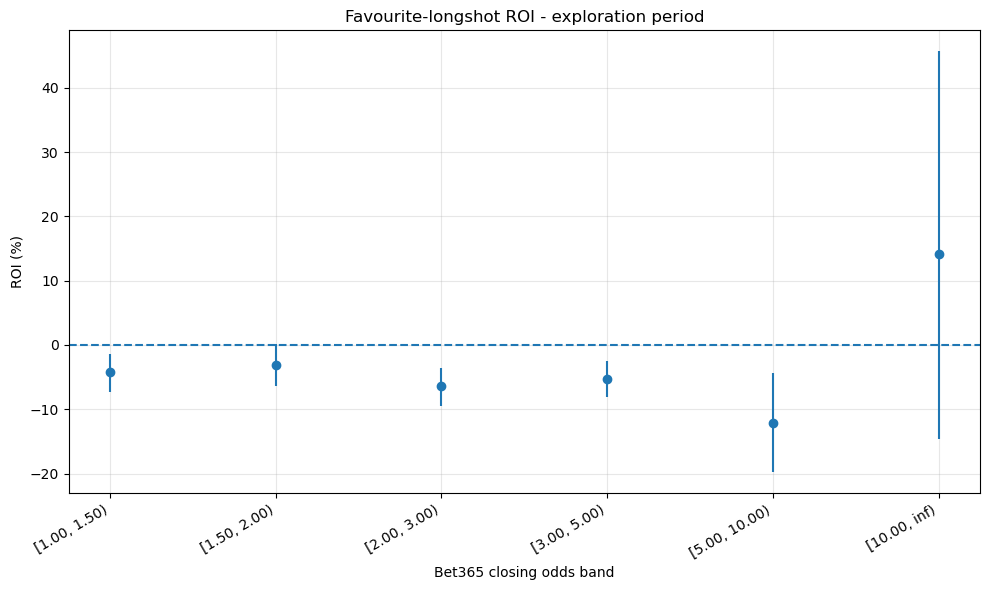

In [20]:
plot_roi_by_band(
    exploration_overall,
    "Favourite-longshot ROI - exploration period",
)

### Exploration calibration check

Compare observed win rates with proportional Bet365 no-vig probabilities within the same odds bands. This separates probability calibration from bettor profitability, which are related but not equivalent questions.


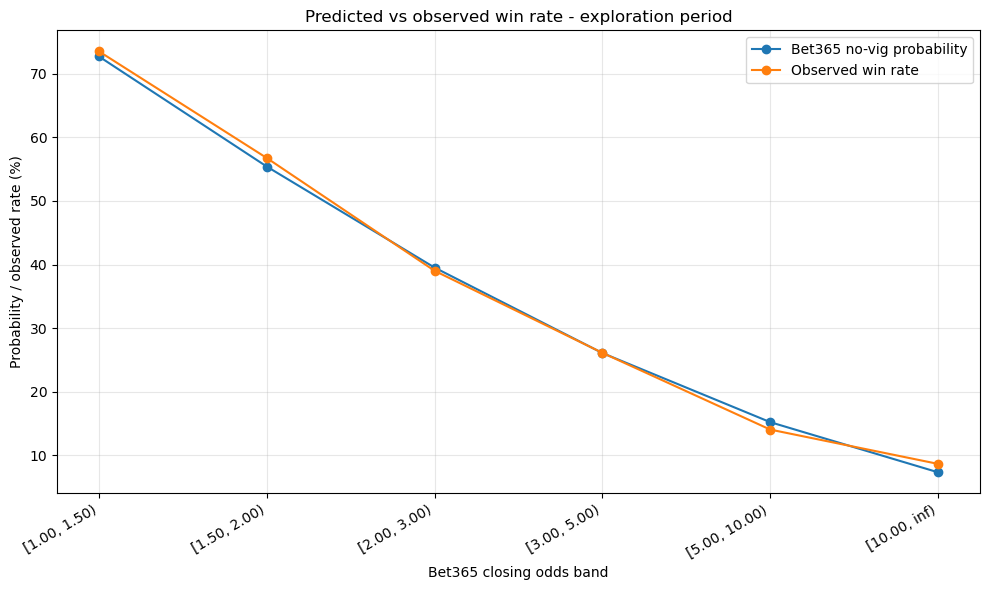

In [21]:
plot_data = (
    exploration_overall.loc[
        (~exploration_overall["sparse"])
        & exploration_overall[
            "mean_predicted_probability"
        ].notna()
    ]
    .copy()
)

x = np.arange(len(plot_data))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    plot_data["mean_predicted_probability"] * 100,
    marker="o",
    label="Bet365 no-vig probability",
)

plt.plot(
    x,
    plot_data["win_rate"] * 100,
    marker="o",
    label="Observed win rate",
)

plt.xticks(
    x,
    plot_data["odds_band"],
    rotation=30,
    ha="right",
)

plt.xlabel("Bet365 closing odds band")
plt.ylabel("Probability / observed rate (%)")
plt.title(
    "Predicted vs observed win rate - exploration period"
)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Test de-vig sensitivity in the exploration period

Compare proportional and power no-vig probabilities. If the apparent calibration pattern changes materially between the two methods, the result should be described as sensitive to the margin-removal assumption rather than as robust probability mispricing.


In [22]:
exploration_power = add_bootstrap_intervals(
    df_exploration,
    probability_col="b365_power_no_vig_probability",
    seed=RANDOM_SEED + 100,
)

devig_sensitivity_exploration = (
    exploration_overall[
        [
            "odds_band",
            "n_bets",
            "win_rate",
            "mean_predicted_probability",
            "calibration_gap",
            "gap_ci_low",
            "gap_ci_high",
            "sparse",
        ]
    ]
    .rename(
        columns={
            "mean_predicted_probability":
                "proportional_probability",
            "calibration_gap":
                "proportional_gap",
            "gap_ci_low":
                "proportional_gap_ci_low",
            "gap_ci_high":
                "proportional_gap_ci_high",
        }
    )
    .merge(
        exploration_power[
            [
                "odds_band",
                "mean_predicted_probability",
                "calibration_gap",
                "gap_ci_low",
                "gap_ci_high",
            ]
        ].rename(
            columns={
                "mean_predicted_probability":
                    "power_probability",
                "calibration_gap":
                    "power_gap",
                "gap_ci_low":
                    "power_gap_ci_low",
                "gap_ci_high":
                    "power_gap_ci_high",
            }
        ),
        on="odds_band",
        how="left",
    )
)

devig_sensitivity_exploration[
    "probability_difference"
] = (
    devig_sensitivity_exploration[
        "power_probability"
    ]
    - devig_sensitivity_exploration[
        "proportional_probability"
    ]
)

display(devig_sensitivity_exploration)

,odds_band,n_bets,win_rate,proportional_probability,proportional_gap,proportional_gap_ci_low,proportional_gap_ci_high,sparse,power_probability,power_gap,power_gap_ci_low,power_gap_ci_high,probability_difference
0,"[1.00, 1.50)",1483,0.734997,0.726963,0.008033,-0.015507,0.029161,False,0.752791,-0.017795,-0.040411,0.003917,0.025828
1,"[1.50, 2.00)",2589,0.567401,0.553961,0.013439,-0.005603,0.032921,False,0.567001,0.000399,-0.018609,0.019499,0.013040
2,"[2.00, 3.00)",4242,0.390146,0.395171,-0.005025,-0.017976,0.007222,False,0.398491,-0.008345,-0.020439,0.004076,0.003319
3,"[3.00, 5.00)",9561,0.261165,0.260891,0.000274,-0.007496,0.007762,False,0.256446,0.004719,-0.002586,0.012235,-0.004445
4,"[5.00, 10.00)",3108,0.140605,0.152267,-0.011662,-0.023880,0.000519,False,0.141011,-0.000406,-0.011959,0.011435,-0.011256
5,"[10.00, inf)",623,0.086677,0.073460,0.013218,-0.007903,0.036444,False,0.059556,0.027122,0.005756,0.049463,-0.013904


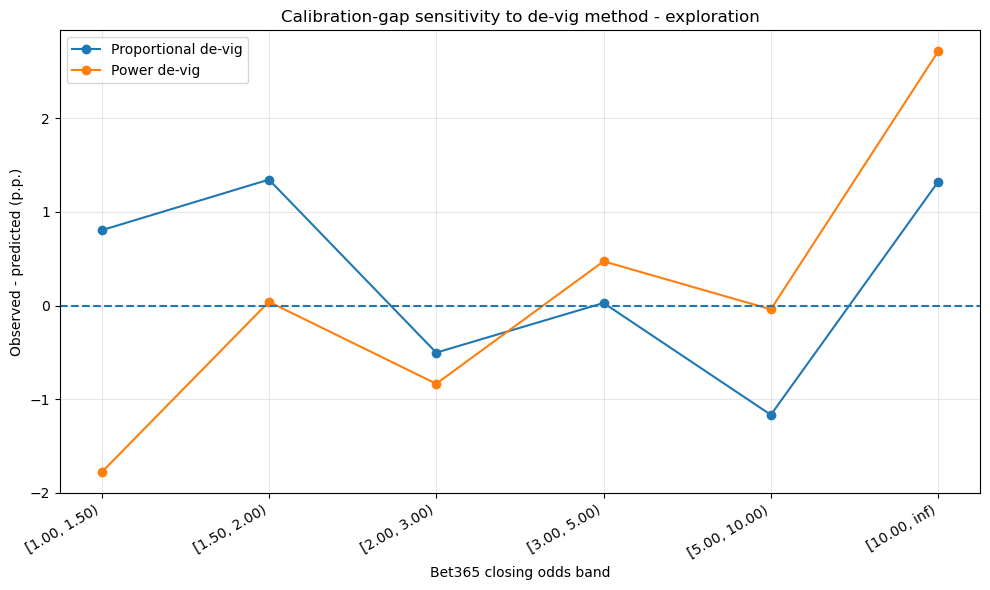

In [23]:
plot_data = (
    devig_sensitivity_exploration.loc[
        ~devig_sensitivity_exploration["sparse"]
    ]
    .copy()
)

x = np.arange(len(plot_data))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    plot_data["proportional_gap"] * 100,
    marker="o",
    label="Proportional de-vig",
)

plt.plot(
    x,
    plot_data["power_gap"] * 100,
    marker="o",
    label="Power de-vig",
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xticks(
    x,
    plot_data["odds_band"],
    rotation=30,
    ha="right",
)

plt.xlabel("Bet365 closing odds band")
plt.ylabel("Observed - predicted (p.p.)")
plt.title(
    "Calibration-gap sensitivity to de-vig method - exploration"
)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Validation protocol

The later seasons were kept untouched while the exploration results were reviewed. Before opening the validation period, the odds bands, sparse threshold, temporal split, de-vig methods, and practical hypotheses were frozen.

The final repository version has `RUN_VALIDATION = True` because that protocol has already been completed. The purpose of this section is to document the holdout procedure, not to invite further tuning after seeing the validation results.


## 13. Evaluate the temporal validation period

Run the same pre-defined ROI and calibration calculations on the 2023/24 to 2025/26 holdout without changing the rules chosen during exploration.


In [24]:
validation_overall = None
validation_power = None
temporal_validation = None

if not RUN_VALIDATION:
    print(
        "Validation is locked. "
        "Freeze the exploration interpretation first, "
        "then set RUN_VALIDATION = True."
    )

else:
    df_validation = (
        df_roi.loc[
            df_roi["analysis_period"] == "validation"
        ]
        .copy()
    )

    validation_overall = add_bootstrap_intervals(
        df_validation,
        probability_col=(
            "b365_prop_no_vig_probability"
        ),
        seed=RANDOM_SEED + 200,
    )

    validation_power = add_bootstrap_intervals(
        df_validation,
        probability_col=(
            "b365_power_no_vig_probability"
        ),
        seed=RANDOM_SEED + 300,
    )

    temporal_validation = pd.concat(
        [
            exploration_overall.assign(
                analysis_period="exploration"
            ),
            validation_overall.assign(
                analysis_period="validation"
            ),
        ],
        ignore_index=True,
    )

    display(validation_overall)

,odds_band,n_bets,n_matches,wins,total_profit,mean_odds,median_odds,mean_raw_implied_probability,mean_predicted_probability,roi,...,calibration_gap,sparse,roi_ci_low,roi_ci_high,win_rate_ci_low,win_rate_ci_high,predicted_ci_low,predicted_ci_high,gap_ci_low,gap_ci_high
0,"[1.00, 1.50)",1024,1024,778,-2.77,1.322617,1.33,0.761111,0.720349,-0.002705,...,0.039417,False,-0.037316,0.033659,0.733463,0.786904,0.716595,0.724053,0.014189,0.066963
1,"[1.50, 2.00)",1969,1969,1103,-71.14,1.733667,1.73,0.580589,0.550016,-0.036130,...,0.010167,False,-0.074069,0.003293,0.538148,0.581935,0.547992,0.552009,-0.011944,0.032187
2,"[2.00, 3.00)",3128,2267,1241,-150.58,2.446189,2.45,0.414427,0.392678,-0.048139,...,0.004061,False,-0.081498,-0.014397,0.382428,0.411299,0.390874,0.394392,-0.010243,0.018272
3,"[3.00, 5.00)",7042,4459,1817,-453.26,3.695757,3.60,0.275073,0.260638,-0.064365,...,-0.002614,False,-0.097447,-0.031254,0.249155,0.267168,0.259767,0.261506,-0.011397,0.006467
4,"[5.00, 10.00)",2231,1803,301,-417.00,6.377633,6.00,0.162390,0.153811,-0.186912,...,-0.018894,False,-0.272445,-0.106149,0.120626,0.148234,0.152814,0.154825,-0.033145,-0.005563
5,"[10.00, inf)",374,339,16,-165.00,13.108289,12.00,0.080499,0.076261,-0.441176,...,-0.033480,False,-0.695664,-0.169269,0.024211,0.062803,0.074776,0.077733,-0.052304,-0.013183


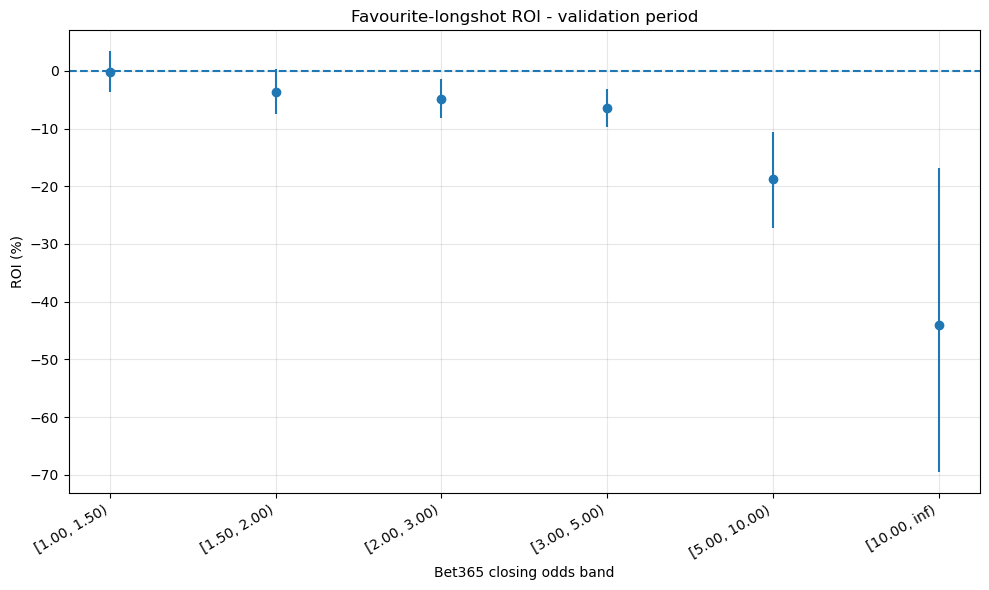

In [25]:
if RUN_VALIDATION:
    plot_roi_by_band(
        validation_overall,
        "Favourite-longshot ROI - validation period",
    )

### Compare exploration with validation

A pattern becomes more credible when its direction and broad shape survive the later-period holdout. A result that reverses strongly in validation is treated as unstable rather than rescued with new cutoffs or subgroup filters.


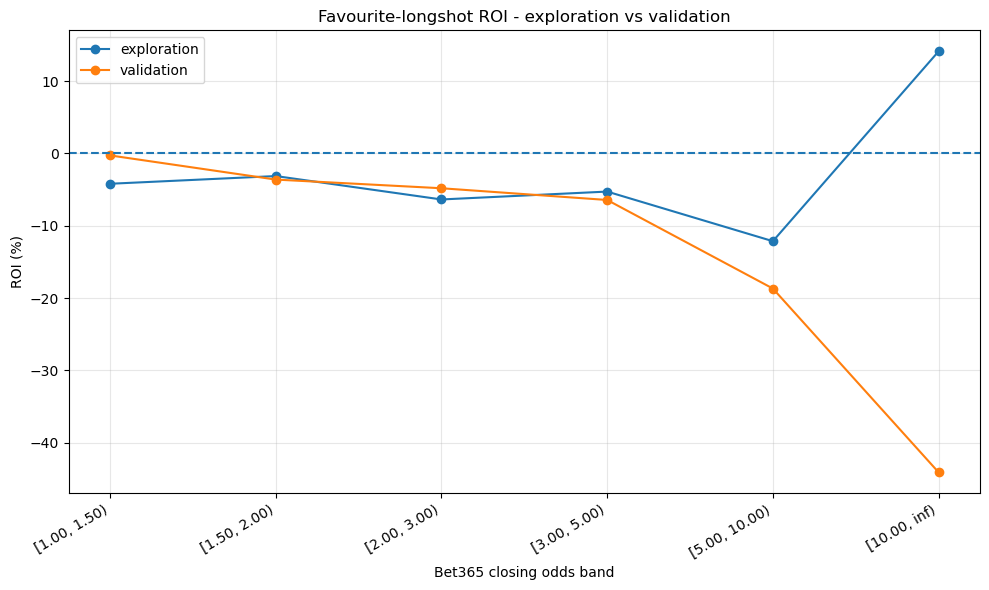

In [26]:
if RUN_VALIDATION:
    plot_data = temporal_validation.loc[
        ~temporal_validation["sparse"]
    ].copy()

    x_all = np.arange(N_ODDS_BANDS)

    plt.figure(figsize=(10, 6))

    for period in ["exploration", "validation"]:
        subset = plot_data.loc[
            plot_data["analysis_period"] == period
        ]

        y = np.full(
            N_ODDS_BANDS,
            np.nan,
            dtype=float,
        )

        for _, row in subset.iterrows():
            band_index = ODDS_BAND_LABELS.index(
                str(row["odds_band"])
            )
            y[band_index] = row["roi"] * 100

        plt.plot(
            x_all,
            y,
            marker="o",
            label=period,
        )

    plt.axhline(
        0,
        linestyle="--",
    )

    plt.xticks(
        x_all,
        ODDS_BAND_LABELS,
        rotation=30,
        ha="right",
    )

    plt.xlabel("Bet365 closing odds band")
    plt.ylabel("ROI (%)")
    plt.title(
        "Favourite-longshot ROI - exploration vs validation"
    )
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 14. Build the final full-sample tables

After the holdout has been evaluated, combine all seasons for the final descriptive tables and Power BI exports. These full-sample estimates summarize the complete dataset, while the temporal split remains the stronger protection against post-hoc pattern selection.


In [27]:
full_overall = None
roi_by_selection = None
roi_by_league = None
roi_by_season = None
full_power = None
devig_sensitivity_full = None

if not RUN_VALIDATION:
    print(
        "Full-sample result tables remain locked "
        "until temporal validation is explicitly opened."
    )

else:
    full_overall = add_bootstrap_intervals(
        df_roi,
        probability_col=(
            "b365_prop_no_vig_probability"
        ),
        seed=RANDOM_SEED + 400,
    )

    display(full_overall)

,odds_band,n_bets,n_matches,wins,total_profit,mean_odds,median_odds,mean_raw_implied_probability,mean_predicted_probability,roi,...,calibration_gap,sparse,roi_ci_low,roi_ci_high,win_rate_ci_low,win_rate_ci_high,predicted_ci_low,predicted_ci_high,gap_ci_low,gap_ci_high
0,"[1.00, 1.50)",2507,2507,1868,-64.95,1.314898,1.33,0.765694,0.724262,-0.025907,...,0.020852,False,-0.047339,-0.003404,0.729559,0.762231,0.721840,0.726603,0.004768,0.037627
1,"[1.50, 2.00)",4558,4558,2572,-152.08,1.726233,1.72,0.583142,0.552257,-0.033366,...,0.012026,False,-0.058557,-0.008088,0.549596,0.578591,0.551006,0.553647,-0.002623,0.026336
2,"[2.00, 3.00)",7370,5397,2896,-420.57,2.437858,2.40,0.415924,0.394113,-0.057065,...,-0.001169,False,-0.079487,-0.033947,0.383289,0.402603,0.392899,0.395248,-0.010669,0.008653
3,"[3.00, 5.00)",16603,10556,4314,-957.49,3.692089,3.60,0.275275,0.260784,-0.057670,...,-0.000951,False,-0.080629,-0.035755,0.253795,0.265757,0.260218,0.261319,-0.006903,0.004975
4,"[5.00, 10.00)",5339,4384,738,-794.30,6.414741,6.00,0.161522,0.152912,-0.148773,...,-0.014684,False,-0.206917,-0.094053,0.129044,0.146638,0.152298,0.153540,-0.023846,-0.006260
5,"[10.00, inf)",997,903,70,-77.00,13.552156,12.00,0.078704,0.074511,-0.077232,...,-0.004300,False,-0.285844,0.163958,0.054509,0.086577,0.073564,0.075430,-0.020109,0.012312


### ROI by outcome type

Check whether the same fixed odds bands behave differently for home, draw, and away selections.


In [28]:
if RUN_VALIDATION:
    selection_order = ["H", "D", "A"]

    roi_by_selection = build_segmented_roi_tables(
        df_roi,
        segment_col="selection_type",
        segment_values=selection_order,
        probability_col=(
            "b365_prop_no_vig_probability"
        ),
        seed_start=RANDOM_SEED + 500,
    )

    display(roi_by_selection)

,selection_type,odds_band,n_bets,n_matches,wins,total_profit,mean_odds,median_odds,mean_raw_implied_probability,mean_predicted_probability,...,calibration_gap,sparse,roi_ci_low,roi_ci_high,win_rate_ci_low,win_rate_ci_high,predicted_ci_low,predicted_ci_high,gap_ci_low,gap_ci_high
0,H,"[1.00, 1.50)",1909,1909,1433,-48.16,1.305804,1.33,0.771317,0.729556,...,0.021099,False,-0.050616,0.001768,0.730931,0.770910,0.726697,0.732429,0.001912,0.041102
1,H,"[1.50, 2.00)",3005,3005,1669,-151.05,1.723913,1.72,0.584027,0.553157,...,0.002251,False,-0.080343,-0.020788,0.537934,0.572716,0.551541,0.554806,-0.015118,0.019084
2,H,"[2.00, 3.00)",3929,3929,1538,-305.29,2.392107,2.37,0.423437,0.401275,...,-0.009827,False,-0.113480,-0.042686,0.376409,0.406090,0.399829,0.402720,-0.024889,0.004656
3,H,"[3.00, 5.00)",2422,2422,584,-309.99,3.681243,3.60,0.277079,0.262535,...,-0.021412,False,-0.192028,-0.065402,0.223928,0.258530,0.261190,0.264007,-0.038735,-0.004459
4,H,"[5.00, 10.00)",1048,1048,133,-227.00,6.423426,6.00,0.161191,0.152610,...,-0.025702,False,-0.338869,-0.079936,0.107484,0.148589,0.151028,0.154172,-0.045234,-0.003588
5,H,"[10.00, inf)",145,145,10,-11.00,12.255172,12.00,0.084274,0.079758,...,-0.010793,True,-0.615625,0.548656,0.028986,0.115109,0.077660,0.081814,-0.050734,0.035120
6,D,"[1.00, 1.50)",0,0,0,0.00,NaN,NaN,NaN,NaN,...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,D,"[1.50, 2.00)",0,0,0,0.00,NaN,NaN,NaN,NaN,...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,D,"[2.00, 3.00)",332,332,112,-11.99,2.857771,2.90,0.350264,0.331073,...,0.006276,False,-0.182314,0.107818,0.285705,0.387888,0.329952,0.332287,-0.045261,0.056792
9,D,"[3.00, 5.00)",10289,10289,2758,-331.53,3.670704,3.60,0.276219,0.261662,...,0.006391,False,-0.063122,-0.001562,0.259529,0.276586,0.261078,0.262257,-0.002046,0.014849


### ROI by league

Repeat the fixed-band analysis for each league. League-level results are secondary evidence and should be interpreted with their sample sizes and bootstrap intervals.


In [29]:
if RUN_VALIDATION:
    league_order = sorted(
        df_roi["div"].unique()
    )

    roi_by_league = build_segmented_roi_tables(
        df_roi,
        segment_col="div",
        segment_values=league_order,
        probability_col=(
            "b365_prop_no_vig_probability"
        ),
        seed_start=RANDOM_SEED + 600,
    )

    display(roi_by_league)

,div,odds_band,n_bets,n_matches,wins,total_profit,mean_odds,median_odds,mean_raw_implied_probability,mean_predicted_probability,...,calibration_gap,sparse,roi_ci_low,roi_ci_high,win_rate_ci_low,win_rate_ci_high,predicted_ci_low,predicted_ci_high,gap_ci_low,gap_ci_high
0,D1,"[1.00, 1.50)",459,459,341,-22.11,1.291176,1.30,0.780944,0.738685,...,0.004235,False,-0.101669,0.002432,0.703089,0.781056,0.732374,0.744928,-0.035973,0.042910
1,D1,"[1.50, 2.00)",773,773,422,-53.66,1.727684,1.73,0.582907,0.551977,...,-0.006052,False,-0.127046,-0.009214,0.511284,0.580855,0.548767,0.555148,-0.040076,0.028526
2,D1,"[2.00, 3.00)",1305,910,502,-105.43,2.423946,2.40,0.418048,0.395935,...,-0.011261,False,-0.130991,-0.029269,0.363134,0.407241,0.393439,0.398452,-0.032918,0.011164
3,D1,"[3.00, 5.00)",2793,1742,745,-13.66,3.775926,3.75,0.268735,0.254459,...,0.012279,False,-0.059830,0.048602,0.251969,0.280652,0.253054,0.255771,-0.002250,0.026082
4,D1,"[5.00, 10.00)",871,660,113,-167.25,6.445178,6.00,0.160739,0.152145,...,-0.022409,False,-0.328324,-0.058059,0.108666,0.150575,0.150529,0.153864,-0.043450,-0.001472
5,D1,"[10.00, inf)",225,188,19,40.00,14.035556,13.00,0.076703,0.072659,...,0.011785,False,-0.325668,0.718362,0.049774,0.121212,0.070793,0.074595,-0.023700,0.048248
6,E0,"[1.00, 1.50)",613,613,449,-32.10,1.304731,1.33,0.772003,0.731159,...,0.001304,False,-0.098119,-0.006956,0.697631,0.767522,0.726037,0.736475,-0.032467,0.035235
7,E0,"[1.50, 2.00)",996,996,567,-27.14,1.722972,1.72,0.584254,0.553810,...,0.015468,False,-0.080842,0.023349,0.538298,0.598981,0.550955,0.556632,-0.015639,0.044656
8,E0,"[2.00, 3.00)",1420,1051,555,-93.92,2.421289,2.40,0.418507,0.397048,...,-0.006203,False,-0.115168,-0.017758,0.369475,0.411605,0.394497,0.399620,-0.027157,0.014663
9,E0,"[3.00, 5.00)",3447,2181,890,-172.14,3.735030,3.60,0.271827,0.257790,...,0.000405,False,-0.094209,-0.002535,0.246052,0.270738,0.256655,0.259039,-0.011718,0.012870


### ROI by season

Compare the same odds bands across seasons to assess temporal consistency without redefining the bands for each year.


In [30]:
if RUN_VALIDATION:
    season_order = (
        EXPLORATION_SEASONS
        + VALIDATION_SEASONS
    )

    roi_by_season = build_segmented_roi_tables(
        df_roi,
        segment_col="season",
        segment_values=season_order,
        probability_col=(
            "b365_prop_no_vig_probability"
        ),
        seed_start=RANDOM_SEED + 700,
    )

    display(roi_by_season)

,season,odds_band,n_bets,n_matches,wins,total_profit,mean_odds,median_odds,mean_raw_implied_probability,mean_predicted_probability,...,calibration_gap,sparse,roi_ci_low,roi_ci_high,win_rate_ci_low,win_rate_ci_high,predicted_ci_low,predicted_ci_high,gap_ci_low,gap_ci_high
0,2019_20,"[1.00, 1.50)",371,371,277,-14.30,1.294474,1.300,0.778337,0.736123,...,0.010508,False,-0.098959,0.017166,0.701797,0.789776,0.729786,0.742768,-0.034261,0.052751
1,2019_20,"[1.50, 2.00)",610,610,336,-34.67,1.721967,1.720,0.584650,0.553484,...,-0.002664,False,-0.124526,0.009339,0.510734,0.589136,0.549851,0.557093,-0.042110,0.035764
2,2019_20,"[2.00, 3.00)",1011,744,398,-54.52,2.436597,2.400,0.416192,0.394612,...,-0.000942,False,-0.112920,0.006662,0.368578,0.419292,0.391303,0.398029,-0.025384,0.024386
3,2019_20,"[3.00, 5.00)",2264,1435,600,-78.81,3.690570,3.600,0.275456,0.261012,...,0.004006,False,-0.093961,0.024238,0.249444,0.280966,0.259442,0.262514,-0.011403,0.019769
4,2019_20,"[5.00, 10.00)",739,608,99,-105.25,6.498309,6.000,0.159528,0.150971,...,-0.017006,False,-0.283594,0.016404,0.111575,0.157676,0.149352,0.152633,-0.039118,0.006847
5,2019_20,"[10.00, inf)",180,156,15,34.00,14.600000,13.000,0.075253,0.071237,...,0.012096,True,-0.377201,0.851648,0.044582,0.127173,0.068841,0.073543,-0.026080,0.055142
6,2020_21,"[1.00, 1.50)",392,392,285,-17.56,1.315714,1.330,0.764997,0.722534,...,0.004507,False,-0.102088,0.012810,0.683511,0.770020,0.716691,0.728460,-0.038937,0.048498
7,2020_21,"[1.50, 2.00)",645,645,375,-6.21,1.719829,1.720,0.585213,0.553538,...,0.027857,False,-0.076258,0.053809,0.542399,0.617742,0.550109,0.556979,-0.010667,0.064202
8,2020_21,"[2.00, 3.00)",1073,788,413,-76.12,2.432488,2.400,0.417011,0.394813,...,-0.009911,False,-0.128901,-0.013293,0.360549,0.410579,0.391880,0.398134,-0.034114,0.014968
9,2020_21,"[3.00, 5.00)",2426,1550,625,-158.43,3.701789,3.600,0.274613,0.259901,...,-0.002276,False,-0.118877,-0.008493,0.243173,0.273099,0.258464,0.261365,-0.016661,0.012995


### Full-sample de-vig sensitivity

Recalculate the calibration comparison with the power method on the full sample to see which probability conclusions are robust to the margin-removal assumption.


In [31]:
if RUN_VALIDATION:
    full_power = add_bootstrap_intervals(
        df_roi,
        probability_col=(
            "b365_power_no_vig_probability"
        ),
        seed=RANDOM_SEED + 800,
    )

    devig_sensitivity_full = (
        full_overall[
            [
                "odds_band",
                "n_bets",
                "win_rate",
                "mean_predicted_probability",
                "calibration_gap",
                "gap_ci_low",
                "gap_ci_high",
                "sparse",
            ]
        ]
        .rename(
            columns={
                "mean_predicted_probability":
                    "proportional_probability",
                "calibration_gap":
                    "proportional_gap",
                "gap_ci_low":
                    "proportional_gap_ci_low",
                "gap_ci_high":
                    "proportional_gap_ci_high",
            }
        )
        .merge(
            full_power[
                [
                    "odds_band",
                    "mean_predicted_probability",
                    "calibration_gap",
                    "gap_ci_low",
                    "gap_ci_high",
                ]
            ].rename(
                columns={
                    "mean_predicted_probability":
                        "power_probability",
                    "calibration_gap":
                        "power_gap",
                    "gap_ci_low":
                        "power_gap_ci_low",
                    "gap_ci_high":
                        "power_gap_ci_high",
                }
            ),
            on="odds_band",
            how="left",
        )
    )

    devig_sensitivity_full[
        "probability_difference"
    ] = (
        devig_sensitivity_full[
            "power_probability"
        ]
        - devig_sensitivity_full[
            "proportional_probability"
        ]
    )

    display(devig_sensitivity_full)

,odds_band,n_bets,win_rate,proportional_probability,proportional_gap,proportional_gap_ci_low,proportional_gap_ci_high,sparse,power_probability,power_gap,power_gap_ci_low,power_gap_ci_high,probability_difference
0,"[1.00, 1.50)",2507,0.745114,0.724262,0.020852,0.004768,0.037627,False,0.749685,-0.004572,-0.021234,0.011909,0.025424
1,"[1.50, 2.00)",4558,0.564283,0.552257,0.012026,-0.002623,0.026336,False,0.565129,-0.000847,-0.014881,0.013060,0.012872
2,"[2.00, 3.00)",7370,0.392944,0.394113,-0.001169,-0.010669,0.008653,False,0.397368,-0.004423,-0.013731,0.005235,0.003255
3,"[3.00, 5.00)",16603,0.259833,0.260784,-0.000951,-0.006903,0.004975,False,0.256360,0.003472,-0.002164,0.009252,-0.004423
4,"[5.00, 10.00)",5339,0.138228,0.152912,-0.014684,-0.023846,-0.006260,False,0.141830,-0.003602,-0.012735,0.005221,-0.011082
5,"[10.00, inf)",997,0.070211,0.074511,-0.004300,-0.020109,0.012312,False,0.060678,0.009533,-0.005367,0.025688,-0.013832


## 15. Plot the final ROI pattern

Show the full-sample ROI by odds band with bootstrap uncertainty. Sparse groups remain in exported tables for transparency but are excluded from the primary chart and from standalone conclusions.


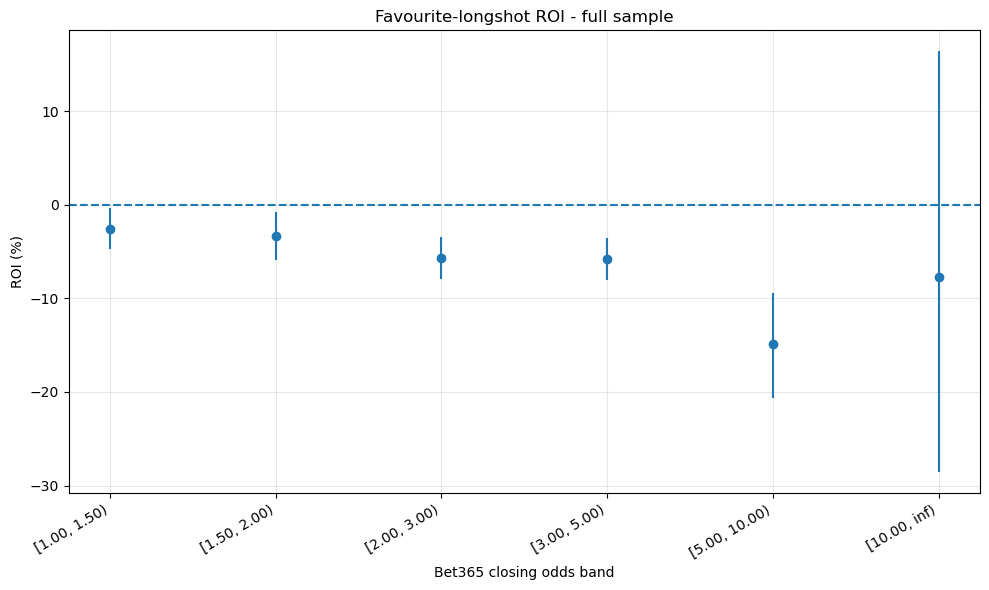

In [32]:
if RUN_VALIDATION:
    plot_roi_by_band(
        full_overall,
        "Favourite-longshot ROI - full sample",
    )

## 16. Validate the final outputs

Run reconciliation checks before export. These tests protect against duplicate analytical keys, incorrect denominators, and malformed confidence intervals.

For percentile bootstrap intervals, the bounds must be finite and correctly ordered. The point estimate is not required to lie inside the percentile interval.


In [33]:
if RUN_VALIDATION:
    assert full_overall["n_bets"].sum() == len(df_roi)

    assert (
        temporal_validation
        .groupby("analysis_period")["n_bets"]
        .sum()
        .to_dict()
        == {
            "exploration": int(
                (df_roi["analysis_period"] == "exploration").sum()
            ),
            "validation": int(
                (df_roi["analysis_period"] == "validation").sum()
            ),
        }
    )

    assert (
        roi_by_selection
        .groupby("selection_type")["n_bets"]
        .sum()
        .eq(
            df_roi.groupby("selection_type").size()
        )
        .all()
    )

    assert (
        roi_by_league
        .groupby("div")["n_bets"]
        .sum()
        .eq(
            df_roi.groupby("div").size()
        )
        .all()
    )

    assert (
        roi_by_season
        .groupby("season")["n_bets"]
        .sum()
        .eq(
            df_roi.groupby("season").size()
        )
        .all()
    )

    assert not roi_by_selection.duplicated(
        ["selection_type", "odds_band"]
    ).any()

    assert not roi_by_league.duplicated(
        ["div", "odds_band"]
    ).any()

    assert not roi_by_season.duplicated(
        ["season", "odds_band"]
    ).any()

    interval_pairs = [
        ("roi_ci_low", "roi_ci_high"),
        ("win_rate_ci_low", "win_rate_ci_high"),
        ("predicted_ci_low", "predicted_ci_high"),
        ("gap_ci_low", "gap_ci_high"),
    ]

    for table in [
        full_overall,
        roi_by_selection,
        roi_by_league,
        roi_by_season,
        temporal_validation,
    ]:
        assert (
            table["sparse"]
            == (table["n_bets"] < MIN_GROUP_N)
        ).all()

        populated = table.loc[
            table["n_bets"] > 0
        ]

        assert populated["roi"].notna().all()
        assert populated["win_rate"].between(0, 1).all()

        for low_col, high_col in interval_pairs:
            assert populated[low_col].notna().all()
            assert populated[high_col].notna().all()
            assert (
                populated[low_col]
                <= populated[high_col]
            ).all()

        assert (
            populated["win_rate_ci_low"]
            .between(0, 1)
            .all()
        )
        assert (
            populated["win_rate_ci_high"]
            .between(0, 1)
            .all()
        )
        assert (
            populated["predicted_ci_low"]
            .between(0, 1)
            .all()
        )
        assert (
            populated["predicted_ci_high"]
            .between(0, 1)
            .all()
        )

    print("Final favourite-longshot outputs validated.")

Final favourite-longshot outputs validated.


## 17. Export Power BI datasets

Write the validated overall, segmented, temporal-validation, de-vig sensitivity, and summary tables to `data/processed/` for the Power BI dashboard.


In [34]:
OUTPUT_DIR = REPO_ROOT / "data" / "processed"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [35]:
if not RUN_VALIDATION:
    print(
        "Final exports skipped because validation "
        "is still locked."
    )

else:
    favourite_longshot_summary = pd.DataFrame({
        "metric": [
            "n_matches",
            "n_bets",
            "mean_b365_overround",
            "median_b365_overround",
            "min_interpretable_group_n",
            "bootstrap_replicates",
        ],
        "value": [
            df_roi["match_id"].nunique(),
            len(df_roi),
            (
                df_roi.groupby("match_id")[
                    "b365_overround"
                ].first().mean()
            ),
            (
                df_roi.groupby("match_id")[
                    "b365_overround"
                ].first().median()
            ),
            MIN_GROUP_N,
            N_BOOTSTRAP,
        ],
    })

    full_overall.to_csv(
        OUTPUT_DIR / "favourite_longshot_overall.csv",
        index=False,
    )

    roi_by_selection.to_csv(
        OUTPUT_DIR / "favourite_longshot_by_selection.csv",
        index=False,
    )

    roi_by_league.to_csv(
        OUTPUT_DIR / "favourite_longshot_by_league.csv",
        index=False,
    )

    roi_by_season.to_csv(
        OUTPUT_DIR / "favourite_longshot_by_season.csv",
        index=False,
    )

    temporal_validation.to_csv(
        OUTPUT_DIR / "favourite_longshot_temporal_validation.csv",
        index=False,
    )

    devig_sensitivity_full.to_csv(
        OUTPUT_DIR / "favourite_longshot_devig_sensitivity.csv",
        index=False,
    )

    favourite_longshot_summary.to_csv(
        OUTPUT_DIR / "favourite_longshot_summary.csv",
        index=False,
    )

    print("Favourite-longshot outputs exported.")

Favourite-longshot outputs exported.


## 18. Interpretation guide

Use the evidence in this order:

1. ROI across the pre-defined Bet365 odds bands with match-cluster bootstrap intervals.
2. Replication or failure to replicate in the untouched validation period.
3. Sensitivity of probability conclusions to the proportional and power de-vig methods.
4. Secondary differences by outcome type, league, and season.
5. Sparse groups as transparent supporting data, not standalone findings.

Avoid moving band boundaries after seeing ROI, selecting only favourable subgroups, treating historical profit as proof of future profitability, or averaging subgroup ROI without the correct underlying weights.

The final project write-up should keep four ideas separate: probability calibration, realized historical return, statistical uncertainty, and temporal validation.


In [36]:
engine.dispose()
print("Database engine disposed.")

Database engine disposed.
